<a href="https://www.kaggle.com/code/tarzon/movie-recommendation-system?scriptVersionId=227861038" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<h1 style="background-color:ffffff;font-size:30px;font-family:Courier;color:#045F5F;font-weight : bold;text-align: center">Movie Recommendation System</h1>

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align: left">Introduction</h1>
Recommender systems are among the most popular applications of data science today. They are used to predict the "rating" or "preference" that a user would give to an item. Almost every major tech company has applied them in some form. Amazon uses it to suggest products to customers, YouTube uses it to decide which video to play next on autoplay, and Facebook uses it to recommend pages to like and people to follow.

There are also popular recommender systems for domains like restaurants, movies, and online dating. Recommender systems have also been developed to explore research articles and experts, collaborators, and financial services. YouTube uses the recommendation system at a large scale to suggest you videos based on your history. For example, if you watch a lot of educational videos, it would suggest those types of videos.


Broadly, recommender systems can be classified into 3 types:

* **Simple recommenders:** offer generalized recommendations to every user, based on movie popularity and/or genre. The basic idea behind this system is that movies that are more popular and critically acclaimed will have a higher probability of being liked by the average audience. An example could be IMDB Top 250.
* **Content-based recommenders:** suggest similar items based on a particular item. This system uses item metadata, such as genre, director, description, actors, etc. for movies, to make these recommendations. The general idea behind these recommender systems is that if a person likes a particular item, he or she will also like an item that is similar to it. And to recommend that, it will make use of the user's past item metadata. A good example could be YouTube, where based on your history, it suggests you new videos that you could potentially watch.
* **Collaborative filtering engines:** these systems are widely used, and they try to predict the rating or preference that a user would give an item-based on past ratings and preferences of other users. Collaborative filters do not require item metadata like its content-based counterparts.

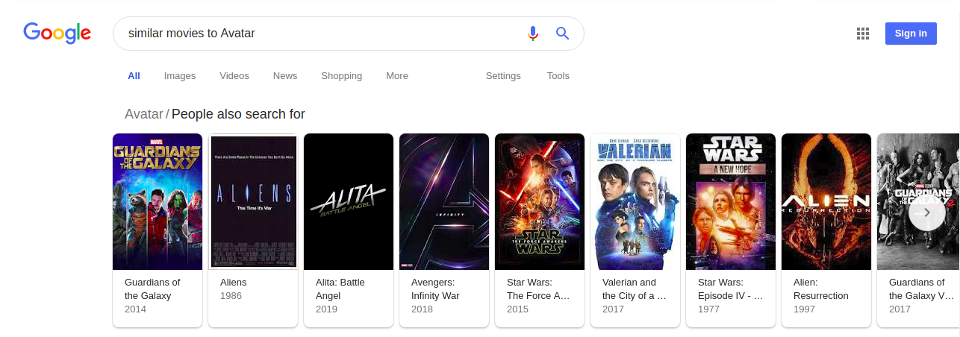

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align: left">Problem Statement</h1>
This notebook involves understanding recommender systems, information filtering, predicting ‘rating’, learning about user ‘preference,’ and so on. We have exclusively worked on data related to user details, movie details, and others. In this notebook, We have apply simple recommender system and generate a list of top 10 movie including labels such as title, genre, total count and rating.

<h1 style="background-color:ffffff;font-size:20px;font-family:Courier;color:#045F5F;font-weight : bold;text-align: left">Let's get started...</h1>

In [2]:
#import libraries
%matplotlib inline
from IPython.display import Image, HTML
import json
import datetime
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor
from wordcloud import WordCloud, STOPWORDS
import plotly
from ast import literal_eval
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
import warnings
warnings.filterwarnings('ignore')


sns.set_style('whitegrid')
sns.set(font_scale=1.25)
pd.set_option('display.max_colwidth', 50)

Let's start with our first "**Simple recommenders**":

In [3]:
# import dataset
df = pd.read_csv('../input/the-movies-dataset/movies_metadata.csv')


In [4]:
#Display  first 5 rows
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [5]:
#Display column labels of the DataFrame.
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')


Features
* adult: Indicates if the movie is X-Rated or Adult.
* belongs_to_collection: A stringified dictionary that gives information on the movie series the particular film belongs to.
* budget: The budget of the movie in dollars.
* genres: A stringified list of dictionaries that list out all the genres associated with the movie.
* homepage: The Official Homepage of the move.
* id: The ID of the move.
* imdb_id: The IMDB ID of the movie.
* original_language: The language in which the movie was originally shot in.
* original_title: The original title of the movie.
* overview: A brief blurb of the movie.
* popularity: The Popularity Score assigned by TMDB.
* poster_path: The URL of the poster image.
* production_companies: A stringified list of production companies involved with the making of the movie.
* production_countries: A stringified list of countries where the movie was shot/produced in.
* release_date: Theatrical Release Date of the movie.
* revenue: The total revenue of the movie in dollars.
* runtime: The runtime of the movie in minutes.
* spoken_languages: A stringified list of spoken languages in the film.
* status: The status of the movie (Released, To Be Released, Announced, etc.)
* tagline: The tagline of the movie.
* title: The Official Title of the movie.
* video: Indicates if there is a video present of the movie with TMDB.
* vote_average: The average rating of the movie.
* vote_count: The number of votes by users, as counted by TMDB.

In [6]:
df.shape

(45466, 24)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [8]:
df.isnull().sum()

adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

We can use the average ratings of the movie as the score but using this won't be fair enough since a movie with 8.9 average rating and only 3 votes cannot be considered better than the movie with 7.8 as average rating but 40 votes. So, I'll be using IMDB's weighted rating (wr) which is given as :-

**WeightedRating(WR)=(v/(v+m)*R)+(m/(v+m)*c)**

In the above equation,

v is the number of votes for the movie;

m is the minimum votes required to be listed in the chart;

R is the average rating of the movie;

C is the mean vote across the whole report.

we already have the values to v (vote_count) and R (vote_average) and C calculates as:

In [9]:
df['genres'] = df['genres'].fillna('[]').apply(literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

In [10]:
# Calculate C mean of vote average column
vote_averages = df[df['vote_average'].notnull()]['vote_average'].astype('int')

C=df['vote_average'].mean()
print(C)

5.618207215134185


So, the average rating of a movies is approx 5.6 on a scale of 10.The next step is to calculate the number of votes, m(the minimum votes required to be listed in the chart), received by a movie in the 90th percentile.In other words, for a movie to be featured in the charts, it must have more votes than at least 90% of the movies on the list.

In [11]:
# Calculate m the minimum number of votes required to be in the chart,
m = df['vote_count'].quantile(0.90)
print(m)

160.0


Now, we can filter out the movies that qualify for the chart

Therefore, to qualify to be considered for the chart, a movie has to have at least 160 votes on TMDB. We also see that the average rating for a movie on TMDB is 5.61 on a scale of 10.

Now, we need to calculate our metric for each qualified movie. To do this, we will define a function, weighted_rating() and define a new feature score, of which we'll calculate the value by applying this function to our DataFrame of qualified movies:

In [12]:
# Filter out all qualified movies into a new DataFrame
q_movies = df.copy().loc[df['vote_count'] >= m]
q_movies.shape

(4555, 24)

In [13]:
# Calculate all the components based on the above formula
v=q_movies['vote_count']
R=q_movies['vote_average']
C=q_movies['vote_average'].mean()
m=q_movies['vote_count'].quantile(0.90)

In [14]:
q_movies['weighted_average']=((R*v)+ (C*m))/(v+m)

In [15]:
q_movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,weighted_average
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,7.347867
1,False,NaN,65000000,"[Adventure, Fantasy, Family]",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,6.697562
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,[Comedy],NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,6.416737
5,False,NaN,60000000,"[Action, Crime, Drama, Thriller]",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0,7.042316
8,False,NaN,35000000,"[Action, Adventure, Thriller]",NaN,9091,tt0114576,en,Sudden Death,International action superstar Jean Claude Van...,...,64350171.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Terror goes into overtime.,Sudden Death,False,5.5,174.0,6.401655


Finally, let's sort the DataFrame in descending order based on the score feature and output the title, genres, vote count, vote average, and weighted_average, popurarity of the top 15 movies.

In [16]:
#Sort movies based on weighted_average calculated above
q_movies_sorted = q_movies.sort_values('weighted_average', ascending=False).head(15)

#Print the top 15 movies
q_movies_sorted[['original_title', 'genres', 'vote_count', 'vote_average' ,'weighted_average','popularity']].head(15)


,original_title,genres,vote_count,vote_average,weighted_average,popularity
314,The Shawshank Redemption,"[Drama, Crime]",8358.0,8.5,8.080643,51.6454
12481,The Dark Knight,"[Drama, Action, Crime, Thriller]",12269.0,8.3,8.024332,123.167
2843,Fight Club,[Drama],9678.0,8.3,7.964103,63.8696
834,The Godfather,"[Drama, Crime]",6024.0,8.5,7.961353,41.1093
292,Pulp Fiction,"[Thriller, Crime]",8670.0,8.3,7.932900,140.95
15480,Inception,"[Action, Thriller, Science Fiction, Mystery, A...",14075.0,8.1,7.881791,29.1081
351,Forrest Gump,"[Comedy, Drama, Romance]",8147.0,8.2,7.835428,48.3072
22879,Interstellar,"[Adventure, Drama, Science Fiction]",11187.0,8.1,7.834650,32.2135
7000,The Lord of the Rings: The Return of the King,"[Adventure, Fantasy, Action]",8226.0,8.1,7.759152,29.3244
1154,The Empire Strikes Back,"[Adventure, Action, Science Fiction]",5998.0,8.2,7.739638,19.471


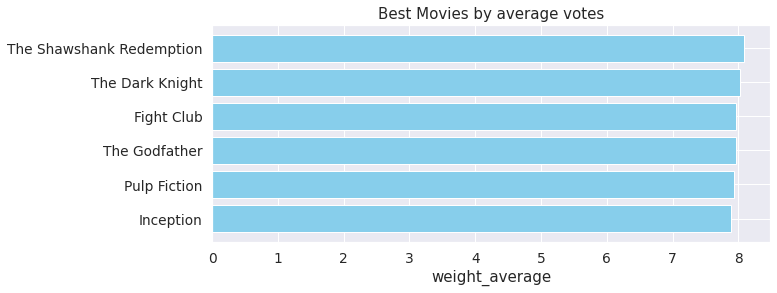

In [17]:
weight_average=q_movies_sorted.sort_values('weighted_average',ascending=False)
plt.figure(figsize=(10,4))

plt.barh(weight_average['original_title'].head(6), weight_average['weighted_average'].head(6), align='center',
        color='skyblue')
plt.xlabel("weight_average")
plt.title("Best Movies by average votes")
plt.gca().invert_yaxis()

As the output, the very top 3 according to our chart is "The Shawshank Redemption","The Dark Knight","fight Club". 

In [ ]:
def clean_numeric(x):
    try:
        return float(x)
    except:
        return np.nan

In [ ]:
q_movies_sorted['popularity'] = q_movies_sorted['popularity'].apply(clean_numeric).astype('float')
q_movies_sorted['vote_count'] = q_movies_sorted['vote_count'].apply(clean_numeric).astype('float')
q_movies_sorted['vote_average'] = q_movies_sorted['vote_average'].apply(clean_numeric).astype('float')


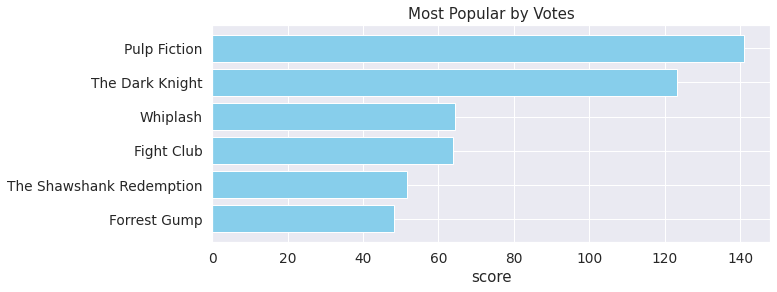

In [47]:
p_pop=q_movies_sorted.sort_values('popularity',ascending=False)

plt.figure(figsize=(10,4))

plt.barh(p_pop['original_title'].head(6),p_pop['popularity'].head(6), align='center',
        color='skyblue')
plt.xlabel("score")
plt.title("Most Popular by Votes")
plt.gca().invert_yaxis()
plt.savefig('Popular Movies.png')

**Recommadation based on scaled avg weight and popularity score**

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaling=MinMaxScaler()

movie_scaled=scaling.fit_transform(q_movies[['weighted_average','popularity']])
movie_normalized=pd.DataFrame(movie_scaled,columns=['weighted_average','popularity'])
movie_normalized.head()

,weighted_average,popularity
0,0.726199,0.040067
1,0.483214,0.031060
2,0.378284,0.015300
3,0.612031,0.032721
4,0.372649,0.009536


In [42]:
q_movies[['normalized_weight_average','normalized_popularity']]= movie_normalized

In [43]:
q_movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,status,tagline,title,video,vote_average,vote_count,weighted_average,normalized_weight_average,normalized_popularity,score
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,Released,NaN,Toy Story,False,7.7,5415.0,7.347867,0.726199,0.040067,0.383133
1,False,NaN,65000000,"[Adventure, Fantasy, Family]",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,6.697562,0.483214,0.031060,0.257137
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,[Comedy],NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,6.416737,0.372649,0.009536,0.191092
5,False,NaN,60000000,"[Action, Crime, Drama, Thriller]",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0,7.042316,0.416237,0.026805,0.221521
8,False,NaN,35000000,"[Action, Adventure, Thriller]",NaN,9091,tt0114576,en,Sudden Death,International action superstar Jean Claude Van...,...,Released,Terror goes into overtime.,Sudden Death,False,5.5,174.0,6.401655,0.437548,0.022156,0.229852


In [44]:
q_movies['score'] = q_movies['normalized_weight_average'] * 0.5 + q_movies['normalized_popularity'] * 0.5
movies_scored = q_movies.sort_values(['score'], ascending=False)
movies_scored[['original_title', 'normalized_weight_average', 'normalized_popularity', 'score']].head(20)

,original_title,normalized_weight_average,normalized_popularity,score
4087,Revenge of the Nerds,0.380709,1.000000,0.690355
4193,City Slickers,0.588799,0.537604,0.563202
3739,The Cell,0.790813,0.282733,0.536773
1338,Jaws,0.857530,0.058559,0.458045
1437,Grosse Pointe Blank,0.839908,0.074958,0.457433
813,Matilda,0.829268,0.060926,0.445097
3146,Buffy the Vampire Slayer,0.859260,0.029364,0.444312
328,Tommy Boy,0.794739,0.064877,0.429808
3928,Save the Last Dance,0.580647,0.266442,0.423544
2585,"South Park: Bigger, Longer & Uncut",0.800094,0.030841,0.415467


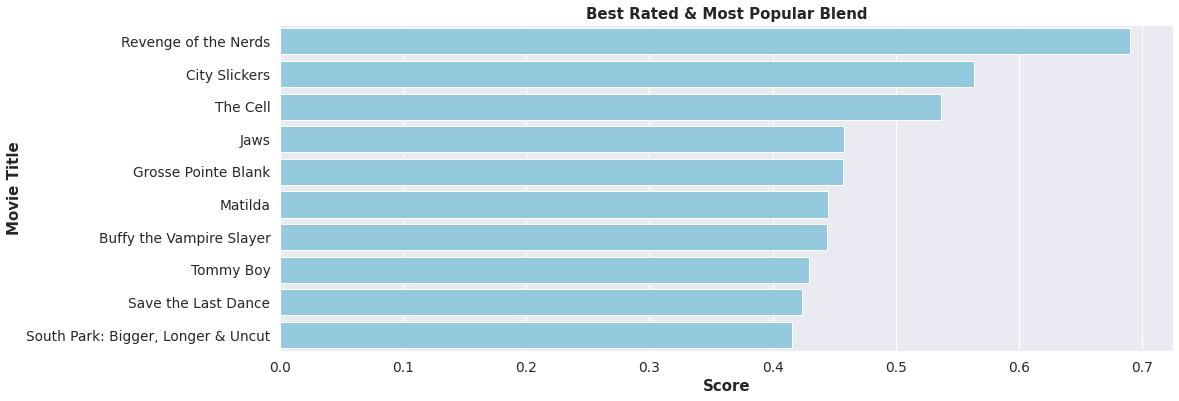

In [46]:
scored_df = q_movies.sort_values('score', ascending=False)


plt.figure(figsize=(16,6))

ax = sns.barplot(x=scored_df['score'].head(10), y=scored_df['original_title'].head(10), color='skyblue')

#plt.xlim(3.55, 5.25)
plt.title('Best Rated & Most Popular Blend', weight='bold')
plt.xlabel('Score', weight='bold')
plt.ylabel('Movie Title', weight='bold')

plt.savefig('scored_movies.png')


**Content Based Recommendation System**


Now lets make a recommendations based on the movie’s plot summaries given in the overview column. So if our user gives us a movie title, our goal is to recommend movies that share similar plot summaries.

In [16]:
df['overview'].head(5)

0    Led by Woody, Andy's toys live happily in his ...
1    When siblings Judy and Peter discover an encha...
2    A family wedding reignites the ancient feud be...
3    Cheated on, mistreated and stepped on, the wom...
4    Just when George Banks has recovered from his ...
Name: overview, dtype: object

In [17]:
df.shape

(45466, 24)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfv = TfidfVectorizer(min_df=3,  max_features=None, 
            strip_accents='unicode', analyzer='word',token_pattern=r'\w{1,}',
            ngram_range=(1, 3),
            stop_words = 'english')

# Filling NaNs with empty string
df['overview'] = df['overview'].fillna('')

In [19]:
# Fitting the TF-IDF on the 'overview' text
tfv_matrix = tfv.fit_transform(df['overview'])

In [20]:
tfv_matrix.shape

(45466, 80190)

In [21]:
from sklearn.metrics.pairwise import sigmoid_kernel

# Compute the sigmoid kernel
sig = sigmoid_kernel(tfv_matrix, tfv_matrix)

In [22]:
# Reverse mapping of indices and movie titles
indices = pd.Series(q_movies.index, index=q_movies['original_title']).drop_duplicates()

In [23]:
indices

original_title
Toy Story                           0
Jumanji                             1
Father of the Bride Part II         4
Heat                                5
Sudden Death                        8
                                ...  
Brice 3                         45177
Girls Trip                      45204
Descendants 2                   45258
Turist                          45265
Les Visiteurs: La Révolution    45343
Length: 4555, dtype: int64

In [24]:
def give_rec(title, sig=sig):
    # Get the index corresponding to original_title
    idx = indices[title]

    # Get the pairwsie similarity scores 
    sig_scores = list(enumerate(sig[idx]))

    # Sort the movies 
    sig_scores = sorted(sig_scores, key=lambda x: x[1], reverse=True)

    # Scores of the 10 most similar movies
    sig_scores = sig_scores[1:11]

    # Movie indices
    movie_indices = [i[0] for i in sig_scores]

    # Top 10 most similar movies
    return df['original_title'].iloc[movie_indices]

In [28]:
# Testing our content-based recommendation system with the seminal film Spy Kids
give_rec('The Dark Knight Rises')

150                                         Batman Forever
12481                                      The Dark Knight
585                                                 Batman
9230                    Batman Beyond: Return of the Joker
1328                                        Batman Returns
15511                           Batman: Under the Red Hood
18035                                     Batman: Year One
35983                                    Batman: Bad Blood
21194    Batman Unmasked: The Psychology of the Dark Kn...
3095                          Batman: Mask of the Phantasm
Name: original_title, dtype: object

In [29]:
give_rec('The Godfather')

1178               The Godfather: Part II
44030    The Godfather Trilogy: 1972-1990
31973                    Honor Thy Father
29                              摇啊摇，摇到外婆桥
23126                          Blood Ties
13177                        I Am the Law
18322                   Un homme est mort
38030                              母を恋はずや
8364                                 Fury
16329               New York Confidential
Name: original_title, dtype: object

**Bravo! we have made our first recommender(Simple Recommendetion system).** 

We have create simple recommenders. This model was very baseline and only provides a fundamental framework to start with.

Please end with your valuable feedback and suggestions.

In [5]:
### Personalized Movie Recommendation System with Data Science

## Step 1: Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, accuracy
from surprise.model_selection import train_test_split

# Load Dataset
df = pd.read_csv("/kaggle/input/the-movies-dataset/movies_metadata.csv")
df.head()


## Step 2: Data Cleaning & Preparation

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)


## Step 3: Content-Based Filtering

# TF-IDF Vectorizer for text data
tfidf = TfidfVectorizer(stop_words='english')
df['overview'].fillna('', inplace=True)
tfidf_matrix = tfidf.fit_transform(df['overview'])

# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Recommendation function
def get_recommendations(title, cosine_sim=cosine_sim):
    idx = df[df['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df['title'].iloc[movie_indices]

# Example recommendation
get_recommendations('Inception')


## Step 4: Collaborative Filtering
# Based on user-item interactions

# Load data for collaborative filtering
data = Dataset.load_builtin('ml-100k')
trainset, testset = train_test_split(data, test_size=0.25)

# Train SVD model
model = SVD()
model.fit(trainset)

# Predict ratings
predictions = model.test(testset)

# Calculate RMSE
rmse = accuracy.rmse(predictions)
print(f"RMSE: {rmse}")


## Step 5: Visualizing Insights

# Top 10 Genres
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='genre', order=df['genre'].value_counts().index[:10])
plt.title("Top 10 Most Popular Genres")
plt.xticks(rotation=45)
plt.show()


## Step 6: Key Takeaways
# Personalized recommendations improve user engagement.
# Combining **Content-Based** and **Collaborative Filtering** creates powerful results.

## Final Thoughts
# Explore the full code and insights in my [Kaggle Notebook](https://www.kaggle.com/code/tarzon/movie-recommendation-system/notebook).


/opt/conda/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3166: DtypeWarning: Columns (10) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


Dataset ml-100k could not be found. Do you want to download it? [Y/n] 

 y


Trying to download dataset from http://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k
RMSE: 0.9385
RMSE: 0.9385182445033652


KeyError: 'genre'

<Figure size 720x432 with 0 Axes>